## Setup

### Datas

In [2]:
import numpy as np
import pandas as pd

### Preprocessing and stuffs

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder,OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline


### Models

In [4]:
# ? randomforrest
from sklearn.ensemble import RandomForestClassifier

# ? xgboost
import xgboost as xgb

# ? pytroch --> for rnns (LSTM/GRU)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

### Plot & visuals

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

### Miscs

In [6]:
# ? SHAP -->  value interpretation
import shap

# tqdm -->  progress bars in loops
from tqdm.auto import tqdm

# ? -->  saving/loading Python objects
import pickle
import joblib
import json


# ? --> random seeds
import random
import os

### Creating the DF

In [7]:
# train_original = pd.read_csv('../Data/proteinas_train.csv')
train_original = pd.read_csv('https://drive.google.com/uc?id=1bclqMvmEwcxGKRqK7NSbaWlfFGcq2RGv')


# test_original = pd.read_csv('../Data/proteinas_test.csv')
test_original = pd.read_csv('https://drive.google.com/uc?id=101nE_gAW32UWgLu2xsxwruQ4IAONwUCQ')

In [8]:
train = train_original.copy()
test = test_original.copy()

In [9]:
train.head(1)

,ID_Proteína,Sequência,Massa_Molecular,Ponto_Isoelétrico,Hidrofobicidade,Carga_Total,Proporção_Polar,Proporção_Apolar,Comprimento_Sequência,Classe
0,TRAIN_P00001,GNMRFVLHDEETHWGTLRTTLNCVPSDIYTISGEDSLFWGMAHPFC...,20362.9468,4.866123,0.149425,-3,0.241379,0.408046,174,Estrutural


In [10]:
test.head(1)

,ID_Proteína,Sequência,Massa_Molecular,Ponto_Isoelétrico,Hidrofobicidade,Carga_Total,Proporção_Polar,Proporção_Apolar,Comprimento_Sequência,Classe
0,TEST_P00001,QWPPEVSNGFQSEGKCRWWFIMDPEKPRFHAHAAFHMPDVFRVHYP...,32373.5883,8.46652,0.143657,20,0.16791,0.38806,268,Receptora


## EDA

In [11]:
train.dtypes

,0
ID_Proteína,object
Sequência,object
Massa_Molecular,float64
Ponto_Isoelétrico,float64
Hidrofobicidade,float64
Carga_Total,int64
Proporção_Polar,float64
Proporção_Apolar,float64
Comprimento_Sequência,int64
Classe,object


In [12]:
test.dtypes

,0
ID_Proteína,object
Sequência,object
Massa_Molecular,float64
Ponto_Isoelétrico,float64
Hidrofobicidade,float64
Carga_Total,int64
Proporção_Polar,float64
Proporção_Apolar,float64
Comprimento_Sequência,int64
Classe,object


In [13]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (16000, 10)
Test shape: (4000, 10)


In [14]:
print("Train info:")
train.info()

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Proteína            16000 non-null  object 
 1   Sequência              16000 non-null  object 
 2   Massa_Molecular        16000 non-null  float64
 3   Ponto_Isoelétrico      16000 non-null  float64
 4   Hidrofobicidade        16000 non-null  float64
 5   Carga_Total            16000 non-null  int64  
 6   Proporção_Polar        16000 non-null  float64
 7   Proporção_Apolar       16000 non-null  float64
 8   Comprimento_Sequência  16000 non-null  int64  
 9   Classe                 16000 non-null  object 
dtypes: float64(5), int64(2), object(3)
memory usage: 1.2+ MB


In [15]:
print("Missing values in train:\n", train.isnull().sum())
print("Missing values in test:\n", test.isnull().sum())

Missing values in train:
 ID_Proteína              0
Sequência                0
Massa_Molecular          0
Ponto_Isoelétrico        0
Hidrofobicidade          0
Carga_Total              0
Proporção_Polar          0
Proporção_Apolar         0
Comprimento_Sequência    0
Classe                   0
dtype: int64
Missing values in test:
 ID_Proteína              0
Sequência                0
Massa_Molecular          0
Ponto_Isoelétrico        0
Hidrofobicidade          0
Carga_Total              0
Proporção_Polar          0
Proporção_Apolar         0
Comprimento_Sequência    0
Classe                   0
dtype: int64


In [16]:
print("Number of duplicate rows in train:", train.duplicated().sum())

Number of duplicate rows in train: 0


In [17]:
pd.set_option('display.max_columns', None)
print("Train descriptive statistics:")
train_stats = train.describe()
print(train_stats)
pd.reset_option('display.max_columns')

Train descriptive statistics:
       Massa_Molecular  Ponto_Isoelétrico  Hidrofobicidade   Carga_Total  \
count     16000.000000       16000.000000     16000.000000  16000.000000   
mean      20708.209250           7.274537         0.149983      8.729938   
std        8678.439780           1.448253         0.027485      7.537891   
min        5463.212900           4.050028         0.014563    -20.000000   
25%       13165.853975           6.048970         0.132911      3.000000   
50%       20597.677000           7.196834         0.150000      8.000000   
75%       28193.961625           8.586190         0.167364     13.000000   
max       37588.751700          11.711987         0.284314     47.000000   

       Proporção_Polar  Proporção_Apolar  Comprimento_Sequência  
count     16000.000000      16000.000000           16000.000000  
mean          0.200260          0.399930             174.033688  
std           0.033875          0.042192              72.920304  
min           0.04918

In [18]:
print("Train categorical statistics:\n", train.describe(include='object'))

Train categorical statistics:
          ID_Proteína                                          Sequência  \
count          16000                                              16000   
unique         16000                                              16000   
top     TRAIN_P15961  SAEINTIMNSFYKVHQQLDPKIEGQGGMDPHPSCDHIWTHPNAIDN...   
freq               1                                                  1   

        Classe  
count    16000  
unique       5  
top     Enzima  
freq      3235  


Class distribution in train:
 Classe
Enzima        3235
Estrutural    3232
Transporte    3225
Outras        3183
Receptora     3125
Name: count, dtype: int64


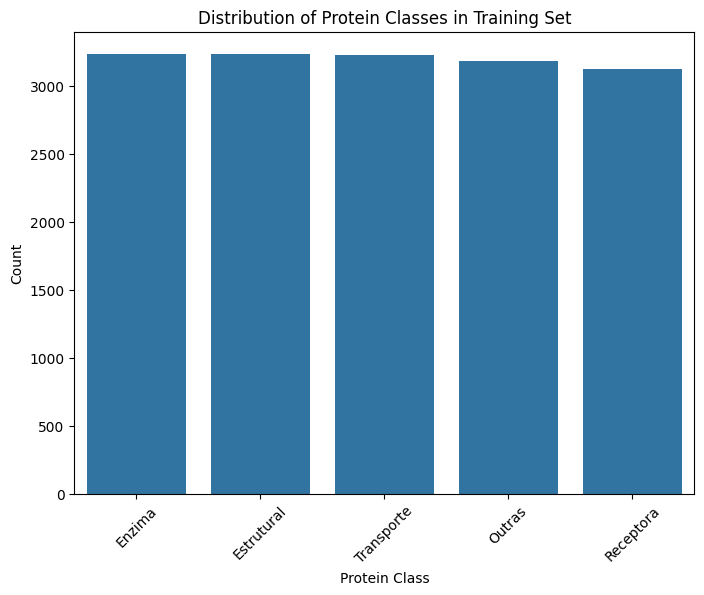

In [19]:
print("Class distribution in train:\n", train['Classe'].value_counts())
plt.figure(figsize=(8, 6))
sns.countplot(data=train, x='Classe', order=train['Classe'].value_counts().index)
plt.title('Distribution of Protein Classes in Training Set')
plt.xlabel('Protein Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

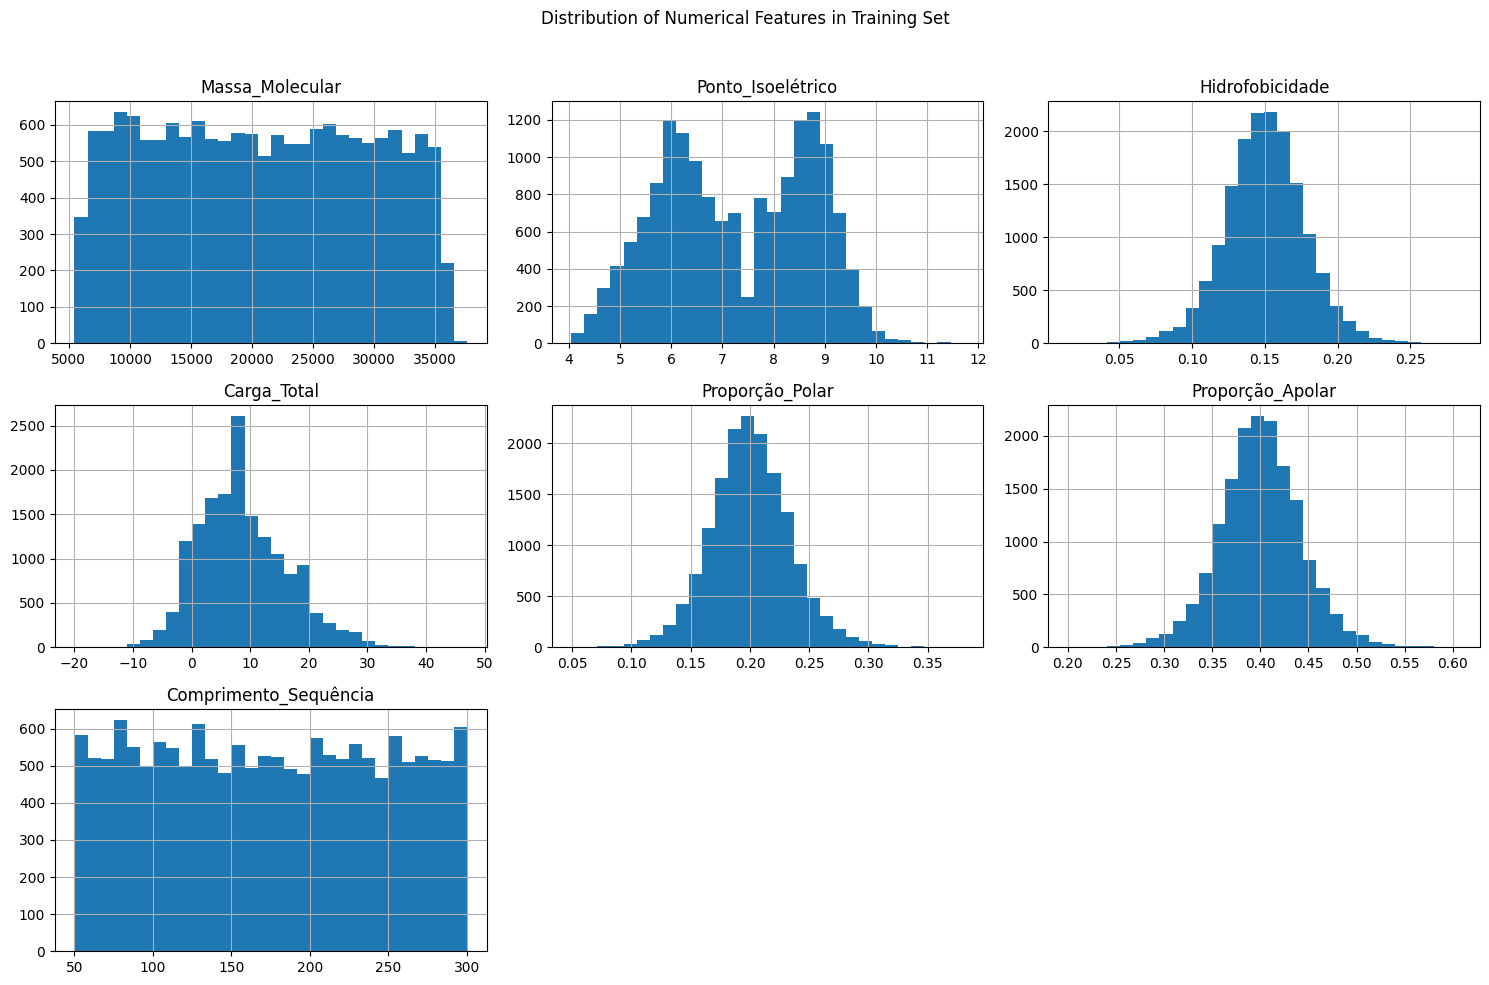

In [20]:
numerical_cols = ['Massa_Molecular', 'Ponto_Isoelétrico', 'Hidrofobicidade', 'Carga_Total', 'Proporção_Polar', 'Proporção_Apolar', 'Comprimento_Sequência']
train[numerical_cols].hist(bins=30, figsize=(15, 10), layout=(3, 3))
plt.suptitle('Distribution of Numerical Features in Training Set')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

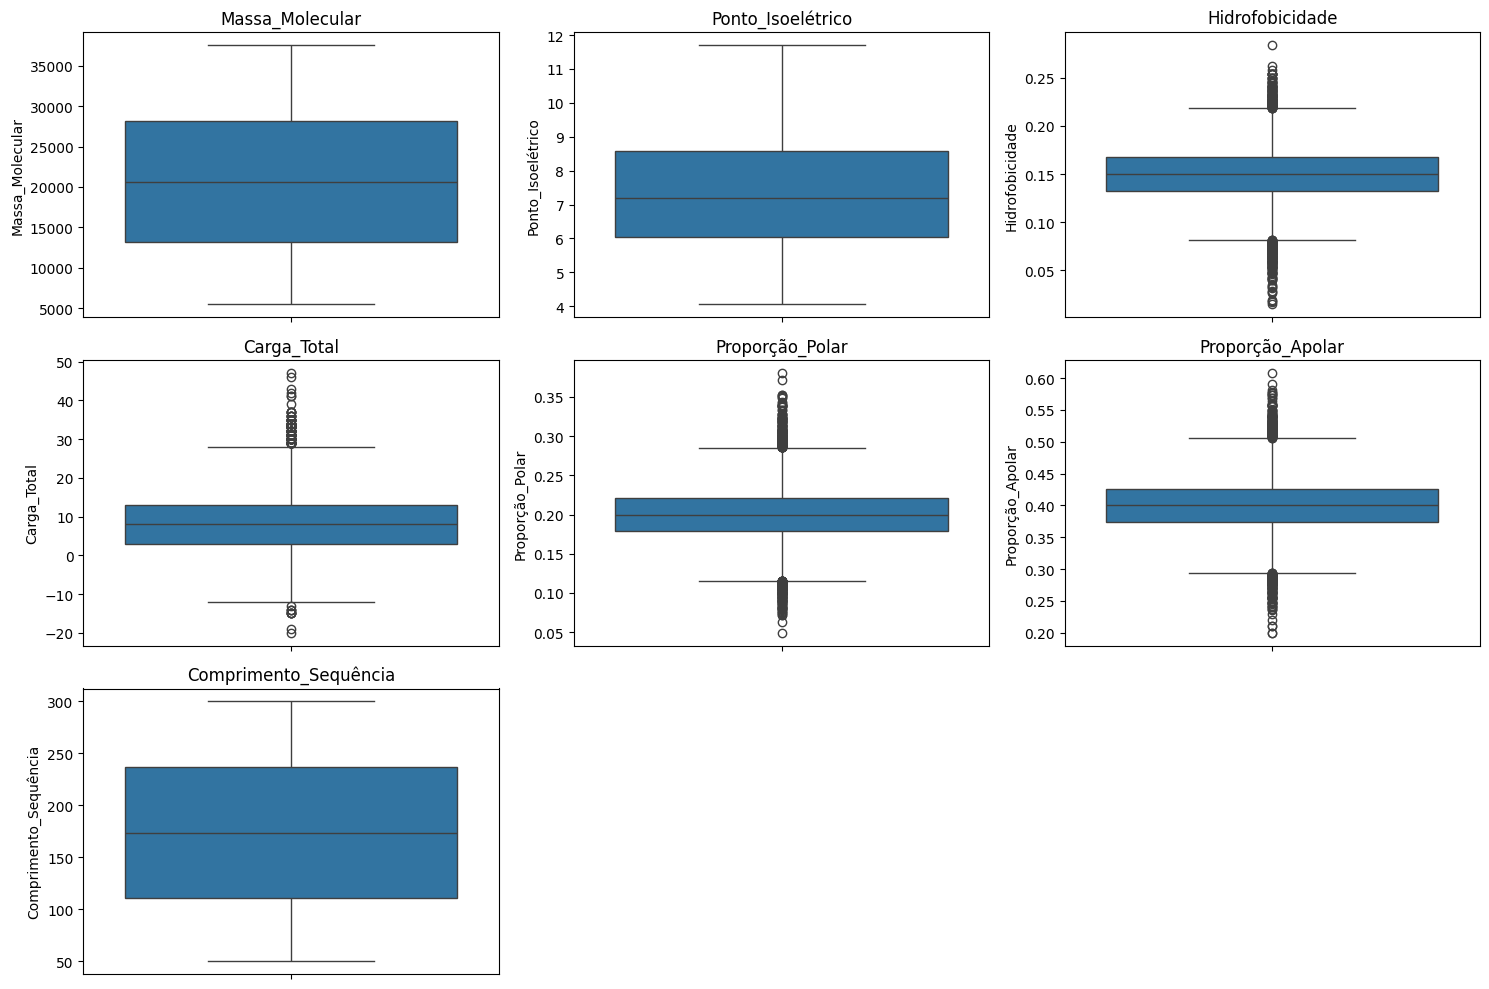

In [21]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=train[col])
    plt.title(col)
plt.tight_layout()
plt.show()

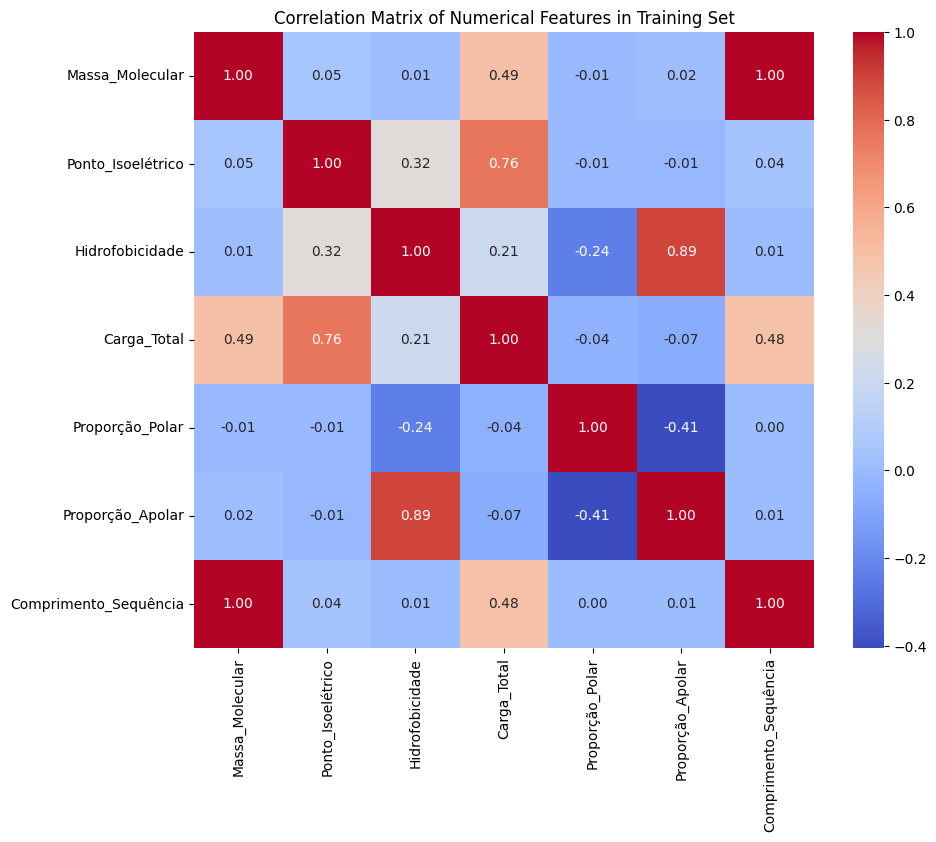

In [22]:
plt.figure(figsize=(10, 8))
correlation_matrix = train[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features in Training Set')
plt.show()

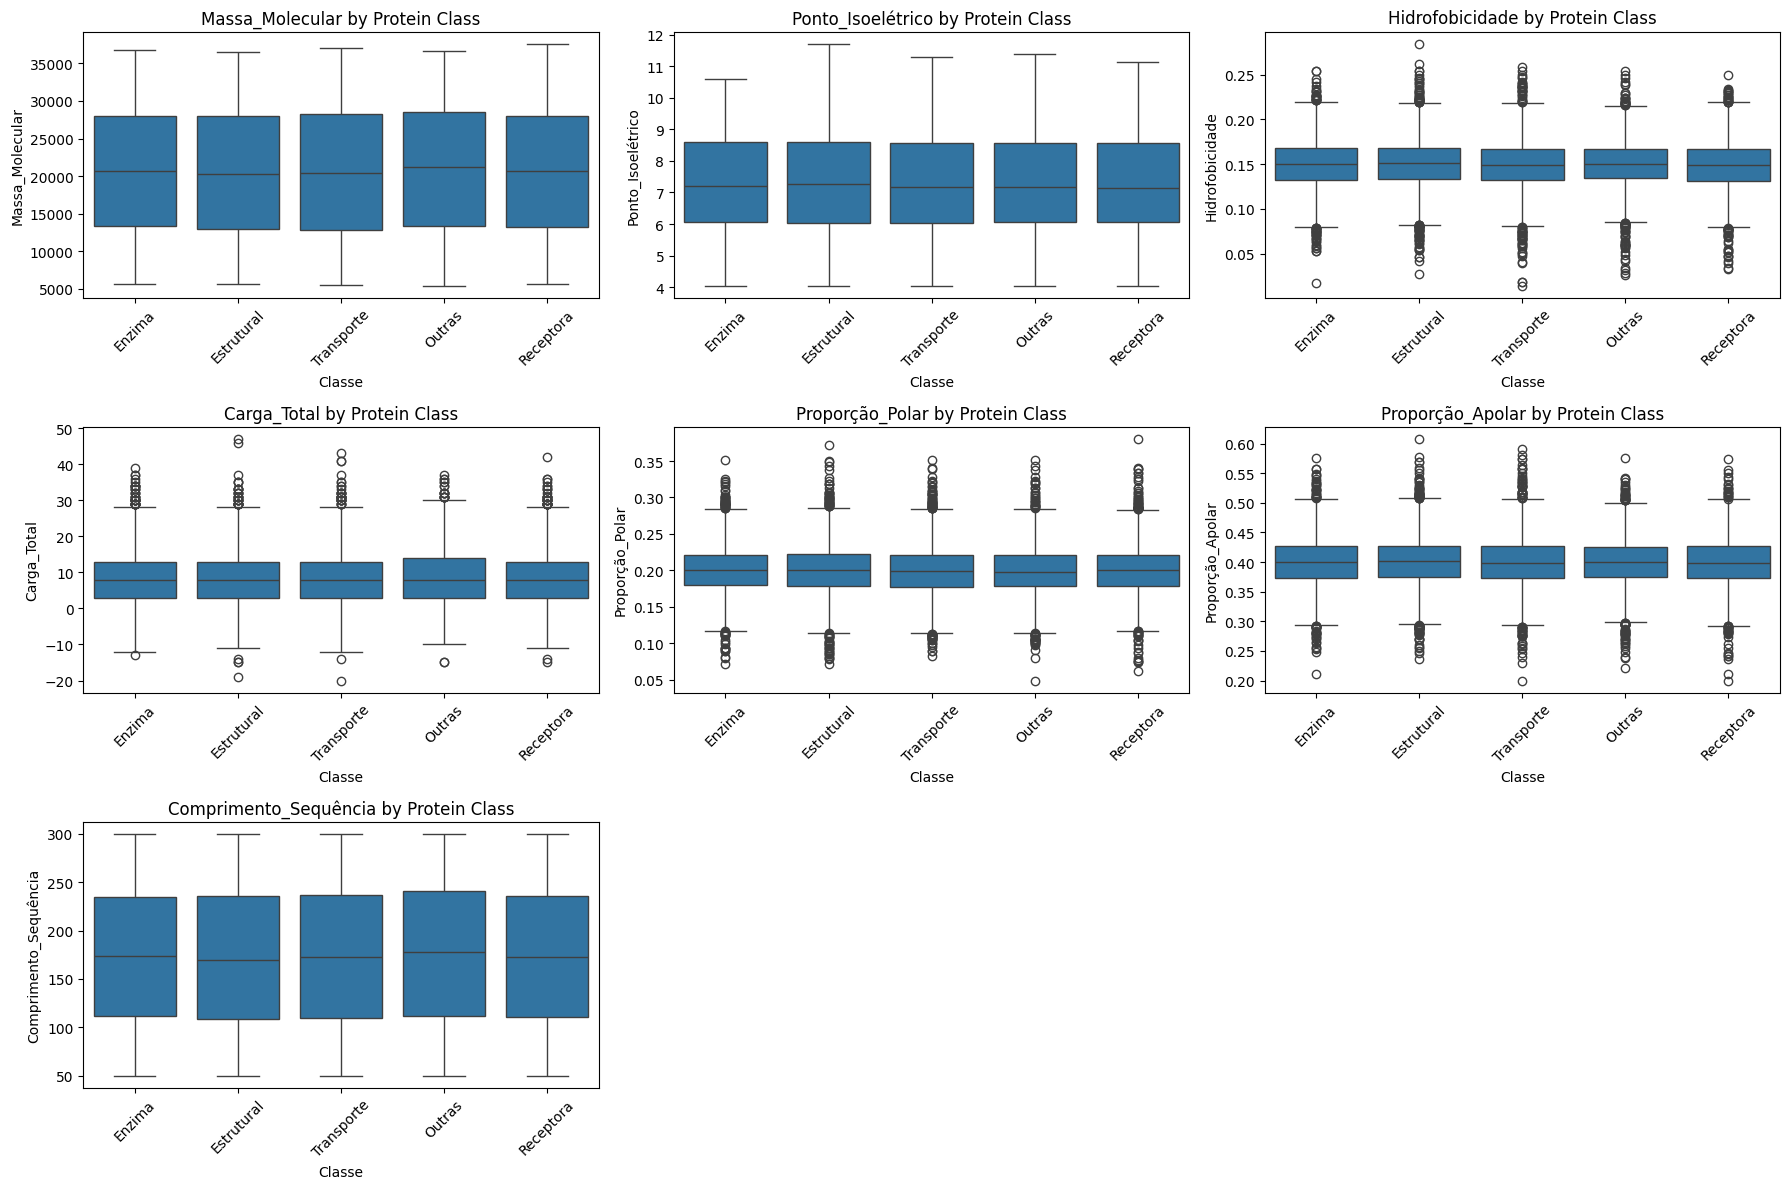

In [23]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=train, x='Classe', y=col, order=train['Classe'].value_counts().index) # ?  ordre by class frequency
    plt.title(f'{col} by Protein Class')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
print(f"Number of unique Protein IDs in train: {train['ID_Proteína'].nunique()}")
print(f"Is ID_Proteína unique? {train['ID_Proteína'].nunique() == len(train)}")

Number of unique Protein IDs in train: 16000
Is ID_Proteína unique? True


In [25]:
sample_sequences = train['Sequência'].sample(5)
all_chars = set()
for seq in sample_sequences:
    all_chars.update(list(seq))
print("Unique characters found in sample sequences:", sorted(list(all_chars)))

Unique characters found in sample sequences: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


-----

## Preprocessing

In [26]:
class FeatureDropper(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop=None):
        self.columns_to_drop = columns_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_transformed = X.copy()
        if self.columns_to_drop:
            cols_to_drop_existing = [col for col in self.columns_to_drop if col in X_transformed.columns]
            X_transformed = X_transformed.drop(columns=cols_to_drop_existing)
        return X_transformed

In [27]:
class CustomScaler(BaseEstimator, TransformerMixin):
    def __init__(self, scaler_type='robust'):
        if scaler_type == 'standard':
            self.scaler = StandardScaler()
        elif scaler_type == 'minmax':
            self.scaler = MinMaxScaler()
        elif scaler_type == 'robust':
            self.scaler = RobustScaler()
        else:
            raise ValueError("scaler_type must be 'standard', 'minmax', or 'robust'")
        self.scaler_type = scaler_type
        self.columns_ = None

    def fit(self, X, y=None):
        self.columns_ = X.columns
        self.index_ = X.index
        self.scaler.fit(X)
        return self

    def transform(self, X):
        if self.columns_ is None:
            raise RuntimeError("Transformer has not been fitted yet!")
        X_scaled_np = self.scaler.transform(X)
        X_transformed = pd.DataFrame(X_scaled_np, columns=self.columns_, index=X.index)
        return X_transformed

In [28]:
class SkewnessCorrector(BaseEstimator, TransformerMixin):
    def __init__(self, skew_threshold=0.75, apply_log_for_positive_skew=False, verbose=False):
        self.skew_threshold = skew_threshold
        self.apply_log_for_positive_skew = apply_log_for_positive_skew
        self.verbose = verbose
        self.log1p_cols_ = []
        self.power_transformers_ = {}

    def fit(self, X, y=None):
        if self.verbose:
            print("SkewnessCorrector: Starting fit method.")
        X_df = pd.DataFrame(X).copy()
        numerical_cols = X_df.select_dtypes(include=[np.number]).columns
        for col in numerical_cols:
            skewness = X_df[col].skew()
            if self.verbose:
                print(f"SkewnessCorrector: Column '{col}' skewness: {skewness:.2f}")
            if abs(skewness) > self.skew_threshold:
                if self.apply_log_for_positive_skew and skewness > 0:
                    # Check if data is suitable for log1p (all values > -1)
                    if (X_df[col] > -1).all():
                        if self.verbose:
                            print(f"SkewnessCorrector: Identified '{col}' for log1p transformation.")
                        self.log1p_cols_.append(col)
                    else:
                        if self.verbose:
                            print(f"SkewnessCorrector: Column '{col}' is positively skewed but contains values <= -1. Applying Yeo-Johnson instead of log1p.")
                        pt = PowerTransformer(method='yeo-johnson', standardize=False) # Standardize later if needed
                        pt.fit(X_df[col].values.reshape(-1, 1))
                        self.power_transformers_[col] = pt
                else: # For negative skew, or if not applying log for positive skew, or if log not applicable
                    if self.verbose:
                        print(f"SkewnessCorrector: Identified '{col}' for Yeo-Johnson transformation.")
                    pt = PowerTransformer(method='yeo-johnson', standardize=False) # Standardize later in pipeline
                    pt.fit(X_df[col].values.reshape(-1, 1))
                    self.power_transformers_[col] = pt
        if self.verbose:
            print("SkewnessCorrector: Fit method completed.")
        return self

    def transform(self, X):
        if self.verbose:
            print("SkewnessCorrector: Starting transform method.")
        X_transformed = pd.DataFrame(X).copy()
        for col in self.log1p_cols_:
            if col in X_transformed.columns:
                if self.verbose:
                    print(f"SkewnessCorrector: Applying log1p to '{col}'.")
                X_transformed[col] = np.log1p(X_transformed[col])
        for col, pt in self.power_transformers_.items():
            if col in X_transformed.columns:
                if self.verbose:
                    print(f"SkewnessCorrector: Applying Yeo-Johnson to '{col}'.")
                X_transformed[col] = pt.transform(X_transformed[col].values.reshape(-1, 1)).flatten()
        if self.verbose:
            print("SkewnessCorrector: Transform method completed.")
        return X_transformed

In [29]:
class CustomLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = LabelEncoder()
        self.classes_ = None

    def fit(self, y):
        # ? y --> is 1D
        y_series = pd.Series(y).astype(str)
        self.encoder.fit(y_series)
        self.classes_ = self.encoder.classes_
        return self

    def transform(self, y):
        if self.classes_ is None:
            raise RuntimeError("CustomLabelEncoder has not been fitted yet!")
        y_series = pd.Series(y).astype(str)
        y_transformed = self.encoder.transform(y_series)
        return y_transformed

    def fit_transform(self, y):
        self.fit(y)
        return self.transform(y)

    def inverse_transform(self, y_transformed):
        if self.classes_ is None:
            raise RuntimeError("CustomLabelEncoder has not been fitted yet!")
        y_original = self.encoder.inverse_transform(y_transformed)
        return y_original

    def get_class_mapping(self):
        if self.classes_ is not None:
            return {label: index for index, label in enumerate(self.encoder.classes_)}
        return None

#### RNN stuffs

In [30]:
class ProteinSequenceDataset(Dataset):
    def __init__(self, sequences, labels, tokenizer_map, max_seq_length):
        self.sequences = sequences # ?  protein sequence strings
        self.labels = labels       # ? array of numerical labels
        self.tokenizer_map = tokenizer_map # ?  e.g., {'A': 1, 'C': 2, ...}
        self.max_seq_length = max_seq_length
        self.pad_token_id = 0 # ?  assuming 0 --> padding token

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        sequence_str = self.sequences[idx]
        label = self.labels[idx]

        # ? tokenize
        tokenized_sequence = [self.tokenizer_map.get(char, self.pad_token_id) for char in sequence_str] # ? handle unknown chars if any

        # ? pad
        padded_sequence = tokenized_sequence[:self.max_seq_length] # ? shortend if longer
        padded_sequence = padded_sequence + [self.pad_token_id] * (self.max_seq_length - len(padded_sequence)) # ? pDa if shorter
        sequence_tensor = torch.tensor(padded_sequence, dtype=torch.long)
        label_tensor = torch.tensor(label, dtype=torch.long) #  ? assuming labels are single integers for CrossEntropyLoss

        return sequence_tensor, label_tensor

In [31]:
class ProteinRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 n_layers, bidirectional, dropout_p, padding_idx=0):
        super(ProteinRNN, self).__init__()

        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(embedding_dim,
                              hidden_dim,
                              num_layers=n_layers,
                              bidirectional=bidirectional,
                              dropout=dropout_p if n_layers > 1 else 0,
                              batch_first=True)

        self.dropout = nn.Dropout(dropout_p)

        linear_input_features = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(linear_input_features, output_dim)

    def forward(self, text_sequences):
        embedded = self.embedding(text_sequences)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        if self.bidirectional:
            hidden_last_layer = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden_last_layer = hidden[-1,:,:]
        dropped_output = self.dropout(hidden_last_layer)
        final_output = self.fc(dropped_output)

        return final_output

## Pipeline & stuffs

In [32]:
label_encoder_custom = CustomLabelEncoder()
label_encoder_custom.fit(train['Classe'])

class_mapping = label_encoder_custom.get_class_mapping()
print("Class mapping:", class_mapping)

Class mapping: {'Enzima': 0, 'Estrutural': 1, 'Outras': 2, 'Receptora': 3, 'Transporte': 4}


In [33]:
train_set, val_set = train_test_split(train, stratify=train['Classe'], test_size=0.2, random_state=42)

In [34]:
train_set['Classe_encoded'] = label_encoder_custom.transform(train_set['Classe'])
val_set['Classe_encoded'] = label_encoder_custom.transform(val_set['Classe'])

In [35]:
physicochemical_feature_columns = [
    'Massa_Molecular',
    'Ponto_Isoelétrico',
    'Hidrofobicidade',
    'Carga_Total',
    'Proporção_Polar',
    'Proporção_Apolar',
    'Comprimento_Sequência'
]

In [36]:
X_train_final = train_set[physicochemical_feature_columns]
y_train_final = train_set['Classe_encoded']

In [37]:
X_val = val_set[physicochemical_feature_columns]
y_val = val_set['Classe_encoded']

In [38]:
column_to_drop = 'Massa_Molecular' # ? or this shit 'Comprimento_Sequência'
pipeline_physicochemical = Pipeline([
    ('feature_dropper', FeatureDropper(columns_to_drop=[column_to_drop])),
    ('custom_scaler', CustomScaler(scaler_type='robust'))
])
pipeline_physicochemical.fit(X_train_final)

Pipeline(steps=[('feature_dropper',
                 FeatureDropper(columns_to_drop=['Massa_Molecular'])),
                ('custom_scaler', CustomScaler())])

In [39]:
X_train_processed = pipeline_physicochemical.transform(X_train_final)
X_val_processed = pipeline_physicochemical.transform(X_val)
print(X_train_processed.head())
print(y_train_final.head())

       Ponto_Isoelétrico  Hidrofobicidade  Carga_Total  Proporção_Polar  \
11683          -0.497897        -0.033182         -0.6        -1.100753   
2359            0.801595         0.922050          0.0         0.757164   
7570            0.693553         1.378008          1.7        -1.320567   
4331           -0.895199        -0.788017         -1.0        -0.563509   
11395           0.655414         1.170061          1.5        -0.359111   

       Proporção_Apolar  Comprimento_Sequência  
11683          0.372085              -0.341270  
2359           0.402836              -0.420635  
7570           1.284785               0.888889  
4331          -0.263121              -0.928571  
11395          0.894226               0.515873  
11683    3
2359     1
7570     0
4331     2
11395    2
Name: Classe_encoded, dtype: int64


#### RNN stuffs

In [40]:
all_sequences_series = train['Sequência']
unique_chars = set(''.join(all_sequences_series.tolist()))
sorted_chars = sorted(list(unique_chars))
char_to_int = {char: i+1 for i, char in enumerate(sorted_chars)} # ? reseve 0 --> padding
int_to_char = {i+1: char for i, char in enumerate(sorted_chars)}
PAD_TOKEN_ID = 0
VOCAB_SIZE = len(char_to_int) + 1 # ? Plus 1 for --> padding token
print(f"Vocabulary: {char_to_int}")
print(f"Vocabulary Size: {VOCAB_SIZE}")

Vocabulary: {'A': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 9, 'L': 10, 'M': 11, 'N': 12, 'P': 13, 'Q': 14, 'R': 15, 'S': 16, 'T': 17, 'V': 18, 'W': 19, 'Y': 20}
Vocabulary Size: 21


In [41]:
MAX_SEQ_LENGTH = train['Comprimento_Sequência'].max() # ? or  fixed value --> 300
print(f"Chosen MAX_SEQ_LENGTH: {MAX_SEQ_LENGTH}")

Chosen MAX_SEQ_LENGTH: 300


In [42]:
# MAX_SEQ_LENGTH = 100
# print(f"Chosen MAX_SEQ_LENGTH: {MAX_SEQ_LENGTH}")

In [43]:
train_sequences = train_set['Sequência'].tolist()
train_labels = train_set['Classe_encoded'].tolist()
val_sequences = val_set['Sequência'].tolist()
val_labels = val_set['Classe_encoded'].tolist()
char_to_int_map = char_to_int
MAX_LEN = MAX_SEQ_LENGTH

train_pytorch_dataset = ProteinSequenceDataset(train_sequences, train_labels, char_to_int_map, MAX_LEN)
val_pytorch_dataset = ProteinSequenceDataset(val_sequences, val_labels, char_to_int_map, MAX_LEN)

BATCH_SIZE = 32 # ? 64, 128,....
train_dataloader = DataLoader(train_pytorch_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_pytorch_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [44]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [45]:
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 5
N_LAYERS = 2
BIDIRECTIONAL = True
DROPOUT_P = 0.3

In [46]:
model_rnn = ProteinRNN(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, BIDIRECTIONAL, DROPOUT_P)
model_rnn = model_rnn.to(device)

In [47]:
criterion = nn.CrossEntropyLoss()

In [48]:
LEARNING_RATE = 0.001
optimizer = optim.Adam(model_rnn.parameters(), lr=LEARNING_RATE)

## Modelling

In [49]:
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Random Forrest

In [50]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
    # 'class_weight': ['balanced', 'balanced_subsample']
}

In [51]:
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='f1_macro',
    cv=cv_stratified,
    verbose=2,
    n_jobs=-1
)

In [52]:
print("Starting GridSearchCV for Random Forest...")
grid_search_rf.fit(X_train_processed, y_train_final)
print("GridSearchCV for Random Forest finished.")

# ? best parameters & best score
print("\nBest Parameters found by GridSearchCV:")
print(grid_search_rf.best_params_)
print("\nBest F1 Macro score on CV:")
print(grid_search_rf.best_score_)

# ? best estimator
best_rf_model = grid_search_rf.best_estimator_

Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV for Random Forest finished.

Best Parameters found by GridSearchCV:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}

Best F1 Macro score on CV:
0.209912923849847


In [53]:
y_pred_rf = best_rf_model.predict(X_val_processed)
y_pred_proba_rf = best_rf_model.predict_proba(X_val_processed)


--- Random Forest Evaluation on Validation Set ---
Accuracy: 0.2059

Classification Report:
              precision    recall  f1-score   support

      Enzima       0.19      0.19      0.19       647
  Estrutural       0.19      0.19      0.19       646
      Outras       0.21      0.22      0.21       637
   Receptora       0.22      0.21      0.21       625
  Transporte       0.22      0.22      0.22       645

    accuracy                           0.21      3200
   macro avg       0.21      0.21      0.21      3200
weighted avg       0.21      0.21      0.21      3200


Classification Report (numerical labels):
              precision    recall  f1-score   support

           0       0.19      0.19      0.19       647
           1       0.19      0.19      0.19       646
           2       0.21      0.22      0.21       637
           3       0.22      0.21      0.21       625
           4       0.22      0.22      0.22       645

    accuracy                           0.21      

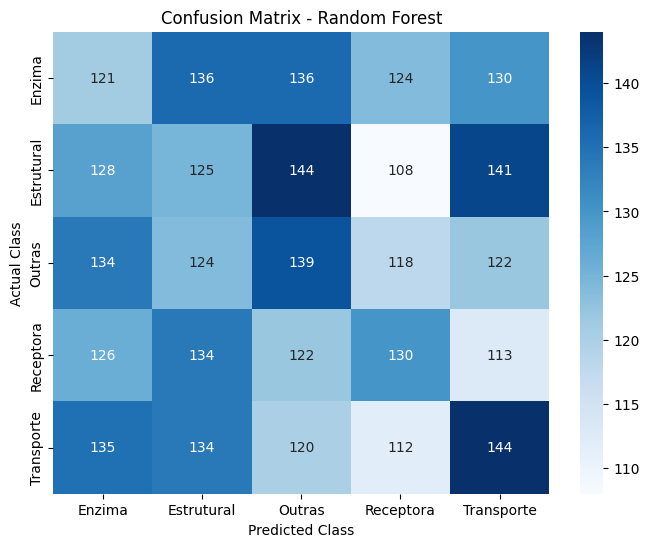

In [54]:
print("\n--- Random Forest Evaluation on Validation Set ---")
accuracy_rf = accuracy_score(y_val, y_pred_rf)
print(f"Accuracy: {accuracy_rf:.4f}")
target_names_for_report = label_encoder_custom.classes_
print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf, target_names=target_names_for_report))
print("\nClassification Report (numerical labels):")
print(classification_report(y_val, y_pred_rf))

roc_auc_rf = roc_auc_score(y_val, y_pred_proba_rf, multi_class='ovr')
print(f"\nROC AUC Score (One-vs-Rest): {roc_auc_rf:.4f}")
print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_val, y_pred_rf)
print(pd.DataFrame(cm_rf))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_for_report if 'target_names_for_report' in locals() else sorted(y_val.unique()),
            yticklabels=target_names_for_report if 'target_names_for_report' in locals() else sorted(y_val.unique()))
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()


Top 10 Feature Importances - Random Forest:
                 feature  importance
0      Ponto_Isoelétrico    0.186842
3        Proporção_Polar    0.183019
1        Hidrofobicidade    0.179238
4       Proporção_Apolar    0.177783
5  Comprimento_Sequência    0.166909
2            Carga_Total    0.106209


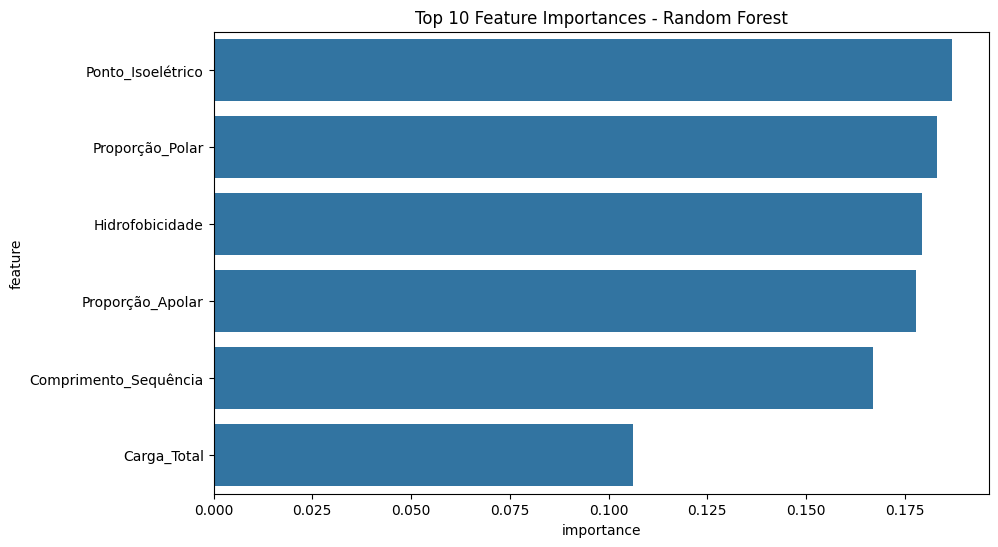

In [55]:
importances_rf = best_rf_model.feature_importances_
feature_names_rf = X_train_processed.columns

feature_importance_df_rf = pd.DataFrame({'feature': feature_names_rf, 'importance': importances_rf})
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='importance', ascending=False)

print("\nTop 10 Feature Importances - Random Forest:")
print(feature_importance_df_rf.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df_rf.head(10))
plt.title('Top 10 Feature Importances - Random Forest')
plt.show()

### xgboost

In [56]:
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
    # 'gamma': [0, 0.1, 0.2]
    # 'objective': ['multi:softmax']
}

In [57]:
xgb_estimator = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

grid_search_xgb = GridSearchCV(
    estimator=xgb_estimator,
    param_grid=param_grid_xgb,
    scoring='f1_macro',         # ? OR 'roc_auc_ovr' etc.
    cv=cv_stratified,
    verbose=2,
    n_jobs=-1
)

In [58]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*use_label_encoder is deprecated and will be removed.*",
    module="xgboost"
)

In [59]:
print("\nStarting GridSearchCV for XGBoost...")
grid_search_xgb.fit(X_train_processed, y_train_final)
print("GridSearchCV for XGBoost finished.")

# ? best parameters & the best score
print("\nBest Parameters found by GridSearchCV (XGBoost):")
print(grid_search_xgb.best_params_)
print("\nBest F1 Macro score on CV (XGBoost):")
print(grid_search_xgb.best_score_)

# ? best estimator
best_xgb_model = grid_search_xgb.best_estimator_


Starting GridSearchCV for XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:47:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV for XGBoost finished.

Best Parameters found by GridSearchCV (XGBoost):
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Best F1 Macro score on CV (XGBoost):
0.21371758923112405


In [60]:
y_pred_xgb = best_xgb_model.predict(X_val_processed)
y_pred_proba_xgb = best_xgb_model.predict_proba(X_val_processed) # ? for roc auc


--- XGBoost Evaluation on Validation Set ---
Accuracy: 0.1891

Classification Report:
              precision    recall  f1-score   support

      Enzima       0.18      0.19      0.19       647
  Estrutural       0.19      0.19      0.19       646
      Outras       0.19      0.19      0.19       637
   Receptora       0.19      0.17      0.18       625
  Transporte       0.20      0.20      0.20       645

    accuracy                           0.19      3200
   macro avg       0.19      0.19      0.19      3200
weighted avg       0.19      0.19      0.19      3200


Classification Report (numerical labels):
              precision    recall  f1-score   support

           0       0.18      0.19      0.19       647
           1       0.19      0.19      0.19       646
           2       0.19      0.19      0.19       637
           3       0.19      0.17      0.18       625
           4       0.20      0.20      0.20       645

    accuracy                           0.19      3200
 

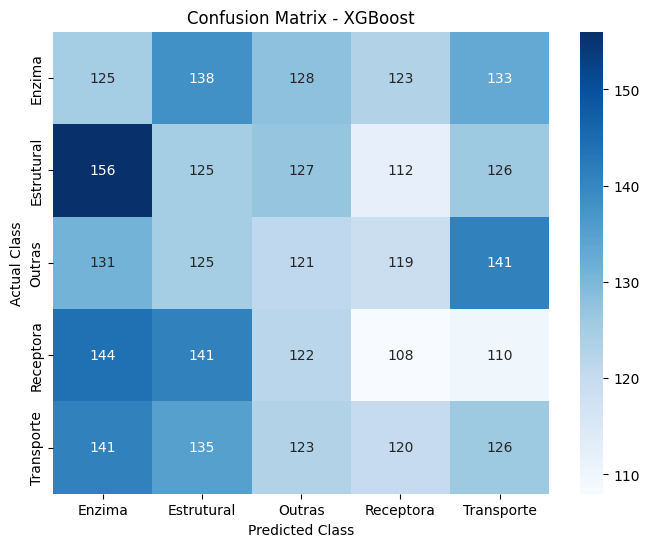

In [61]:
print("\n--- XGBoost Evaluation on Validation Set ---")


accuracy_xgb = accuracy_score(y_val, y_pred_xgb)
print(f"Accuracy: {accuracy_xgb:.4f}")
target_names_for_report = label_encoder_custom.classes_
print("\nClassification Report:")
print(classification_report(y_val, y_pred_xgb, target_names=target_names_for_report))
print("\nClassification Report (numerical labels):")
print(classification_report(y_val, y_pred_xgb))

roc_auc_xgb = roc_auc_score(y_val, y_pred_proba_xgb, multi_class='ovr')
print(f"\nROC AUC Score (One-vs-Rest): {roc_auc_xgb:.4f}")
print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_val, y_pred_xgb)
print(pd.DataFrame(cm_xgb))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_for_report if 'target_names_for_report' in locals() else sorted(y_val.unique()),
            yticklabels=target_names_for_report if 'target_names_for_report' in locals() else sorted(y_val.unique()))
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()


Top 10 Feature Importances - XGBoost:
                 feature  importance
4       Proporção_Apolar    0.170494
1        Hidrofobicidade    0.167800
0      Ponto_Isoelétrico    0.167641
5  Comprimento_Sequência    0.167128
3        Proporção_Polar    0.164833
2            Carga_Total    0.162104


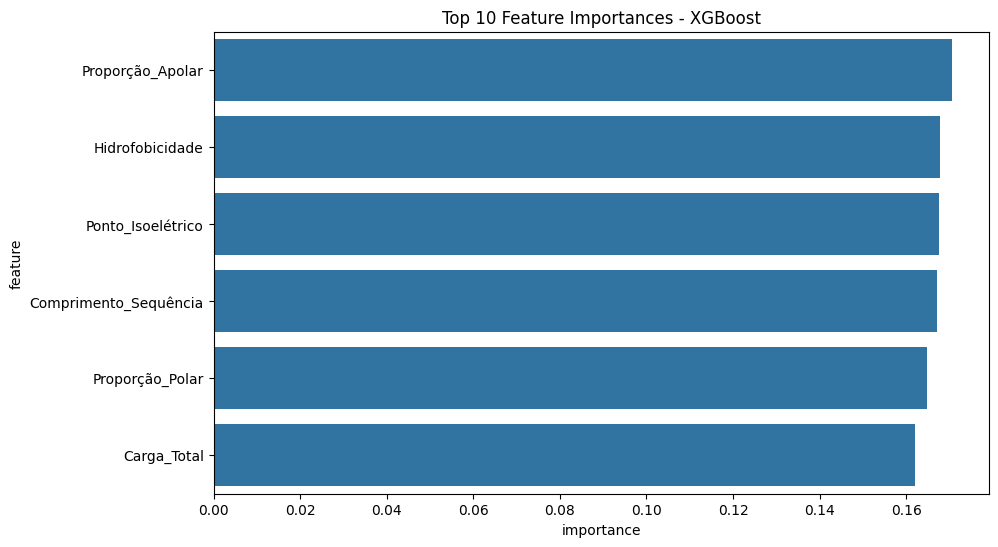

In [62]:
importances_xgb = best_xgb_model.feature_importances_
feature_names_xgb = X_train_processed.columns

feature_importance_df_xgb = pd.DataFrame({'feature': feature_names_xgb, 'importance': importances_xgb})
feature_importance_df_xgb = feature_importance_df_xgb.sort_values(by='importance', ascending=False)

print("\nTop 10 Feature Importances - XGBoost:")
print(feature_importance_df_xgb.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df_xgb.head(10))
plt.title('Top 10 Feature Importances - XGBoost')
plt.show()

### RNNs

In [63]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    epoch_correct_predictions = 0
    total_samples = 0

    for batch_idx, (sequences, labels) in enumerate(dataloader):
        sequences = sequences.to(device)
        labels = labels.to(device)

        # ? zeroing the gradients
        optimizer.zero_grad()

        # ? forward pass
        outputs = model(sequences)

        # ? loss
        loss = criterion(outputs, labels)

        # ? backward pass
        loss.backward()

        # ? update weights
        optimizer.step()

        # ? metrics
        epoch_loss += loss.item() * sequences.size(0) # ? loss.item() ==> avg loss for batch
        _, predicted_labels = torch.max(outputs, 1)
        epoch_correct_predictions += (predicted_labels == labels).sum().item()
        total_samples += labels.size(0)

    avg_epoch_loss = epoch_loss / total_samples
    avg_epoch_acc = epoch_correct_predictions / total_samples
    return avg_epoch_loss, avg_epoch_acc

In [64]:
def evaluate_epoch(model, dataloader, criterion, device):
    model.eval()
    epoch_loss = 0
    epoch_correct_predictions = 0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_probabilities = [] # ? for roc auc

    with torch.no_grad():  # ? no gradient calculations during evaluation
        for sequences, labels in dataloader:
            sequences = sequences.to(device)
            labels = labels.to(device)

            # ? forward pass
            outputs = model(sequences) # ? logits

            # ? loss
            loss = criterion(outputs, labels)

            # ? metrics
            epoch_loss += loss.item() * sequences.size(0)
            _, predicted_labels = torch.max(outputs, 1)
            epoch_correct_predictions += (predicted_labels == labels).sum().item()
            total_samples += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted_labels.cpu().numpy())
            # ? softmax  logits --> probabilities for roc auc
            probabilities = torch.softmax(outputs, dim=1)
            all_probabilities.extend(probabilities.cpu().numpy())

    avg_epoch_loss = epoch_loss / total_samples
    avg_epoch_acc = epoch_correct_predictions / total_samples
    return avg_epoch_loss, avg_epoch_acc, all_labels, all_predictions, np.array(all_probabilities)

In [65]:
NUM_EPOCHS = 20
# NUM_EPOCHS = 10
best_validation_loss = float('inf')
best_model_path = 'best_model_rnn.pth'

print("\nStarting RNN Model Training...")
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model_rnn, train_dataloader, optimizer, criterion, device)
    val_loss, val_acc, _, _, _ = evaluate_epoch(model_rnn, val_dataloader, criterion, device)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
    print(f"\tTrain Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"\t Val. Loss: {val_loss:.4f} |  Val. Acc: {val_acc*100:.2f}%")
    if val_loss < best_validation_loss:
        best_validation_loss = val_loss
        torch.save(model_rnn.state_dict(), best_model_path)
        print(f"\tBest model saved to {best_model_path} (Val Loss: {best_validation_loss:.4f})")
print("RNN Model Training Finished.")


Starting RNN Model Training...
Epoch 1/20:
	Train Loss: 1.6124 | Train Acc: 20.31%
	 Val. Loss: 1.6137 |  Val. Acc: 19.66%
	Best model saved to best_model_rnn.pth (Val Loss: 1.6137)
Epoch 2/20:
	Train Loss: 1.6094 | Train Acc: 21.05%
	 Val. Loss: 1.6107 |  Val. Acc: 20.47%
	Best model saved to best_model_rnn.pth (Val Loss: 1.6107)
Epoch 3/20:
	Train Loss: 1.6072 | Train Acc: 22.23%
	 Val. Loss: 1.6116 |  Val. Acc: 20.78%
Epoch 4/20:
	Train Loss: 1.6035 | Train Acc: 22.62%
	 Val. Loss: 1.6197 |  Val. Acc: 20.06%
Epoch 5/20:
	Train Loss: 1.5944 | Train Acc: 24.48%
	 Val. Loss: 1.6284 |  Val. Acc: 19.69%
Epoch 6/20:
	Train Loss: 1.5755 | Train Acc: 27.21%
	 Val. Loss: 1.6450 |  Val. Acc: 19.91%
Epoch 7/20:
	Train Loss: 1.5416 | Train Acc: 30.52%
	 Val. Loss: 1.6678 |  Val. Acc: 19.47%
Epoch 8/20:
	Train Loss: 1.4919 | Train Acc: 34.55%
	 Val. Loss: 1.7133 |  Val. Acc: 19.12%
Epoch 9/20:
	Train Loss: 1.4230 | Train Acc: 38.94%
	 Val. Loss: 1.7775 |  Val. Acc: 20.41%
Epoch 10/20:
	Train Lo


Loaded best model from best_model_rnn.pth for final validation.

--- RNN Final Evaluation on Validation Set ---
Validation Accuracy: 20.47%
Validation Loss: 1.6107

Classification Report:
              precision    recall  f1-score   support

      Enzima       0.20      0.63      0.31       647
  Estrutural       0.24      0.05      0.08       646
      Outras       0.22      0.12      0.15       637
   Receptora       0.19      0.10      0.13       625
  Transporte       0.20      0.12      0.15       645

    accuracy                           0.20      3200
   macro avg       0.21      0.20      0.16      3200
weighted avg       0.21      0.20      0.16      3200


Classification Report (numerical labels):
              precision    recall  f1-score   support

           0       0.20      0.63      0.31       647
           1       0.24      0.05      0.08       646
           2       0.22      0.12      0.15       637
           3       0.19      0.10      0.13       625
        

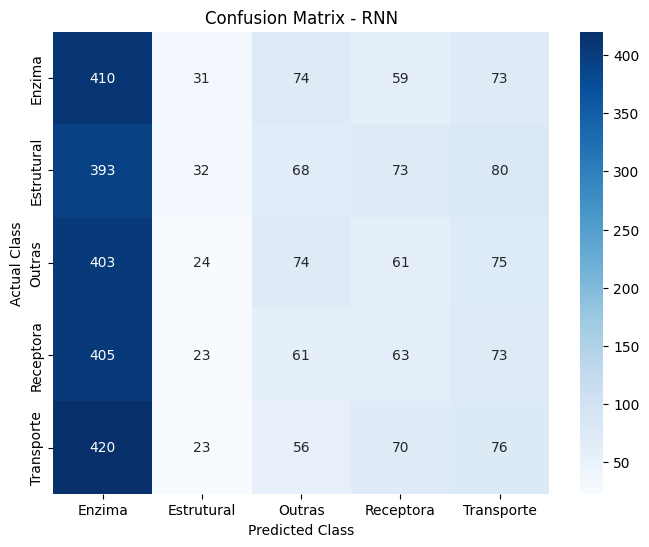

In [66]:
model_rnn.load_state_dict(torch.load(best_model_path))
print(f"\nLoaded best model from {best_model_path} for final validation.")
val_loss_final, val_acc_final, y_val_true_rnn, y_val_pred_rnn, y_val_proba_rnn = evaluate_epoch(model_rnn, val_dataloader, criterion, device)

print("\n--- RNN Final Evaluation on Validation Set ---")
print(f"Validation Accuracy: {val_acc_final*100:.2f}%")
print(f"Validation Loss: {val_loss_final:.4f}")

target_names_for_report = label_encoder_custom.classes_
print("\nClassification Report:")
print(classification_report(y_val_true_rnn, y_val_pred_rnn, target_names=target_names_for_report))
print("\nClassification Report (numerical labels):")
print(classification_report(y_val_true_rnn, y_val_pred_rnn))
roc_auc_rnn = roc_auc_score(y_val_true_rnn, y_val_proba_rnn, multi_class='ovr')
print(f"\nROC AUC Score (One-vs-Rest): {roc_auc_rnn:.4f}")

# Confusion Matrix [cite: 26]
print("\nConfusion Matrix:")
cm_rnn = confusion_matrix(y_val_true_rnn, y_val_pred_rnn)
print(pd.DataFrame(cm_rnn, index=target_names_for_report, columns=target_names_for_report))
# print(pd.DataFrame(cm_rnn))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_for_report if 'target_names_for_report' in locals() else sorted(np.unique(y_val_true_rnn)),
            yticklabels=target_names_for_report if 'target_names_for_report' in locals() else sorted(np.unique(y_val_true_rnn)))
plt.title('Confusion Matrix - RNN')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

## Extracting Models

### Random Forrest Tree & xgboost

In [67]:
if 'best_rf_model' in locals() and best_rf_model is not None:
    joblib.dump(best_rf_model, 'best_rf_model.pkl')
    print("Saved best_rf_model to best_rf_model.pkl")
else:
    print("best_rf_model not found or is None. Skipping save.")

if 'best_xgb_model' in locals() and best_xgb_model is not None:
    joblib.dump(best_xgb_model, 'best_xgb_model.pkl')
    print("Saved best_xgb_model to best_xgb_model.pkl")
else:
    print("best_xgb_model not found or is None. Skipping save.")

if 'pipeline_physicochemical' in locals() and pipeline_physicochemical is not None:
    joblib.dump(pipeline_physicochemical, 'physicochemical_pipeline.pkl')
    print("Saved physicochemical_pipeline to physicochemical_pipeline.pkl")
else:
    print("pipeline_physicochemical not found or is None. Skipping save.")

if 'label_encoder_custom' in locals() and label_encoder_custom is not None:
    joblib.dump(label_encoder_custom, 'label_encoder_custom.pkl')
    print("Saved label_encoder_custom to label_encoder_custom.pkl")
elif 'label_encoder_custom' in locals() and label_encoder_custom is not None:
    joblib.dump(label_encoder_custom, 'label_encoder_custom.pkl')
    print("Saved label_encoder_custom as label_encoder_custom.pkl")
else:
    print("CustomLabelEncoder instance not found or is None. Skipping save.")

Saved best_rf_model to best_rf_model.pkl
Saved best_xgb_model to best_xgb_model.pkl
Saved physicochemical_pipeline to physicochemical_pipeline.pkl
Saved label_encoder_custom to label_encoder_custom.pkl


### RNN (LSTM)

In [69]:
if 'model_rnn' in locals() and model_rnn is not None:
    torch.save(model_rnn.state_dict(), 'best_model_rnn.pth')
    print("Saved model_rnn state_dict to best_model_rnn.pth")
else:
    print("model_rnn not found or is None. Skipping save.")

if 'char_to_int' in locals() and char_to_int is not None:
    joblib.dump(char_to_int, 'char_to_int.pkl')
    print("Saved char_to_int map to char_to_int.pkl")
elif 'char_to_int_map' in locals() and char_to_int_map is not None:
    joblib.dump(char_to_int_map, 'char_to_int.pkl')
    print("Saved char_to_int_map as char_to_int.pkl")
else:
    print("char_to_int map not found or is None. Skipping save.")
rnn_hyperparams = {
    'VOCAB_SIZE': VOCAB_SIZE, 'EMBEDDING_DIM': EMBEDDING_DIM, 'HIDDEN_DIM': HIDDEN_DIM,
    'OUTPUT_DIM': OUTPUT_DIM, 'N_LAYERS': N_LAYERS, 'BIDIRECTIONAL': BIDIRECTIONAL,
    'DROPOUT_P': DROPOUT_P, 'MAX_SEQ_LENGTH': MAX_SEQ_LENGTH
}
with open('rnn_hyperparams.json', 'w') as f:
    json.dump(rnn_hyperparams, f)
print("Saved rnn_hyperparams to rnn_hyperparams.json (example)")

Saved model_rnn state_dict to best_model_rnn.pth
Saved char_to_int map to char_to_int.pkl
Saved rnn_hyperparams to rnn_hyperparams.json (example)
